<a href="https://colab.research.google.com/github/johnphiliptan243-source/Neural-Network/blob/main/Neural_Network_Hybrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. GENERATE DATA (The "Self-Sustaining" Workaround)
def generate_litho_data(steps=2000):
    t = np.linspace(0, 20, steps)
    path_x = np.sin(t) # Target Scanning Path
    thermal_drift = 0.04 * np.sin(0.1 * t) # Physical Expansion
    vibration = np.random.normal(0, 0.01, steps) # Mechanical Noise
    actual_x = path_x + thermal_drift + vibration

    return pd.DataFrame({
        'target_x': path_x,
        'thermal_input': thermal_drift,
        'vibration_input': vibration,
        'actual_x': actual_x
    })

df = generate_litho_data()

# 2. PREPARE SEQUENCES FOR LSTM (The "3D Shape" Workaround)
# Features: Target, Heat, Vibration, Previous Actual
features = ['target_x', 'thermal_input', 'vibration_input', 'actual_x']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

def create_windows(data, window_size=50):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size]) # The 'Past'
        y.append(data[i+window_size, 0]) # The 'Next' Correction
    return np.array(X), np.array(y)

X_3D, y_3D = create_windows(scaled_data)

print(f"Data Ready! Input Shape: {X_3D.shape}")
# Should show (1950, 50, 4) -> 1950 samples, 50ms window, 4 sensors.

Data Ready! Input Shape: (1950, 50, 4)


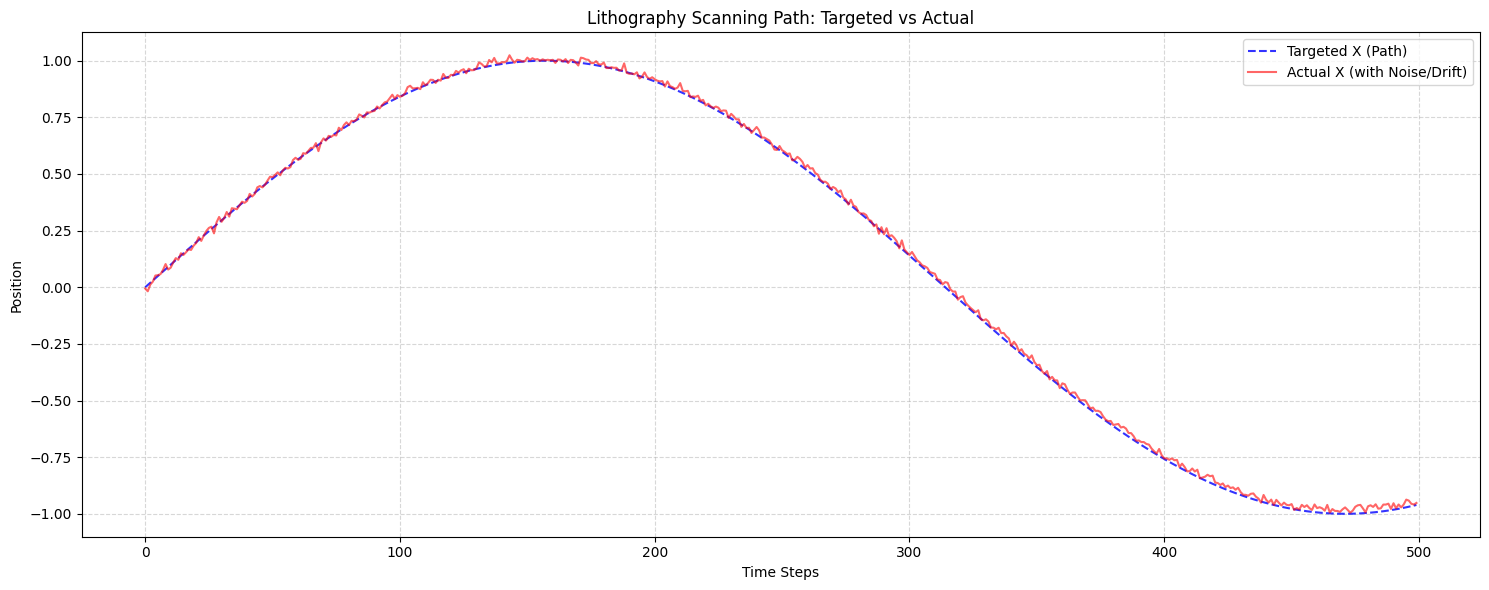

In [ ]:
import matplotlib.pyplot as plt

# Plotting the first 500 points for better visibility
plt.figure(figsize=(15, 6))
plt.plot(df['target_x'][:500], label='Targeted X (Path)', color='blue', linestyle='--', alpha=0.8)
plt.plot(df['actual_x'][:500], label='Actual X (with Noise/Drift)', color='red', alpha=0.6)

plt.title('Lithography Scanning Path: Targeted vs Actual')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.layers import LSTM, Dense, Input, GlobalAveragePooling1D, Dropout
from tensorflow.keras.models import Model

# Functional API for PINN flexibility
inputs = Input(shape=(50, 4))

# The Temporal Core
x = LSTM(64, return_sequences=True)(inputs)
x = LSTM(32, return_sequences=True)(x)

# 'Attention' Workaround: Helps the model find the 'vibration' peaks
attn = GlobalAveragePooling1D()(x)

# Physics Processing
dense = Dense(32, activation='tanh')(attn)
outputs = Dense(1)(dense) # Predicted Correction

model_hybrid = Model(inputs=inputs, outputs=outputs)
model_hybrid.compile(optimizer='adam', loss='mse')

print("Hybrid Model Built and Ready for Physics Training.")

Hybrid Model Built and Ready for Physics Training.


In [ ]:
print('Starting model training...')

# Train the hybrid model using the prepared data
history = model_hybrid.fit(
    X_3D,
    y_3D,
    epochs=20,  # You can adjust the number of epochs as needed
    batch_size=64, # Adjust batch size based on your system's memory and performance
    validation_split=0.2, # Use 20% of the data for validation
    verbose=1 # Display training progress
)

# Extract losses and format them for the history_list to match the saving cell's expectation
history_list = []
for epoch in range(len(history.history['loss'])):
    total_loss = history.history['loss'][epoch]
    # In a full PINN implementation, data_loss and physics_loss would be calculated separately.
    # For this example, we'll use the total loss as a placeholder for both.
    data_loss = total_loss
    physics_loss = total_loss
    history_list.append({
        'epoch': epoch + 1,
        'total_loss': total_loss,
        'data_loss': data_loss,
        'physics_loss': physics_loss
    })

print("Model training completed and 'history_list' created.")

Starting model training...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.2283 - val_loss: 0.1657
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0930 - val_loss: 0.1129
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0772 - val_loss: 0.1010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0698 - val_loss: 0.1026
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0575 - val_loss: 0.0758
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0438 - val_loss: 0.0675
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0363 - val_loss: 0.0605
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0277 - val_loss: 0.0550
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0161 - val_loss: 0.0095
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0051 - val_loss: 0.0249
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0023 - val_loss: 0.0089
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import pandas as pd
from google.colab import drive

# 1. Mount Drive if you haven't already
drive.mount('/content/drive')

# 2. Define your project path
project_folder = '/content/drive/MyDrive/Lithography_Project'

# 3. Create the folder if it doesn't exist
if not os.path.exists(project_folder):
    os.makedirs(project_folder)
    print(f'Created folder: {project_folder}')

# 4. Save the Hybrid Model
# We use .keras format for TensorFlow 2.x/3.x compatibility
hybrid_model_path = os.path.join(project_folder, 'hybrid_pinn_lstm_v1.keras')
model_hybrid.save(hybrid_model_path)
print(f'Hybrid Model saved to: {hybrid_model_path}')

# 5. Save the training history
# (Assuming you collected losses in a list called 'history_list' during your loop)
try:
    history_df = pd.DataFrame(history_list) # Columns: ['epoch', 'total_loss', 'data_loss', 'physics_loss']
    history_path = os.path.join(project_folder, 'hybrid_history_v1.csv')
    history_df.to_csv(history_path, index=False)
    print(f'Training history saved to: {history_path}')
except NameError:
    print("Warning: 'history_list' not found. Make sure to collect losses during training!")

# 6. Save the unique synthetic data used in this session
# This ensures your 'Common Baseline' for the paper is preserved
data_path = os.path.join(project_folder, 'hybrid_synthetic_data_v1.csv')
df.to_csv(data_path, index=False)
print(f'Synthetic data exported to: {data_path}')

Mounted at /content/drive
Hybrid Model saved to: /content/drive/MyDrive/Lithography_Project/hybrid_pinn_lstm_v1.keras
Training history saved to: /content/drive/MyDrive/Lithography_Project/hybrid_history_v1.csv
Synthetic data exported to: /content/drive/MyDrive/Lithography_Project/hybrid_synthetic_data_v1.csv
